In [42]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/pima-indians-diabetes-database/diabetes.csv


In [43]:
!pip install missingno

In [44]:
!pip install pycaret

In [45]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import statsmodels.api as sm
import warnings
warnings.simplefilter("ignore")
import missingno as msno
from datetime import date
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, StandardScaler, RobustScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import KNNImputer
import plotly.offline as py
import plotly.graph_objs as go
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
import plotly.tools as tls
import plotly.figure_factory as ff
py.init_notebook_mode(connected=True)
import squarify

In [46]:
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.float_format', lambda x: '%.5f' % x)

In [47]:
df_ = pd.read_csv("../input/pima-indians-diabetes-database/diabetes.csv")

In [48]:
df = df_.copy()
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.60000,0.62700,50,1
1,1,85,66,29,0,26.60000,0.35100,31,0
2,8,183,64,0,0,23.30000,0.67200,32,1
3,1,89,66,23,94,28.10000,0.16700,21,0
4,0,137,40,35,168,43.10000,2.28800,33,1


In [49]:
def check_df(dataframe, head=5, tail = 5):
    print("##################### Shape #####################")
    print(dataframe.shape)
    print("##################### Types #####################")
    print(dataframe.dtypes)
    print("##################### Head ######################")
    print(dataframe.head(head))
    print("##################### Tail ######################")
    print(dataframe.tail(tail))
    print("##################### NA ########################")
    print(dataframe.isnull().sum())
    print("##################### Quantiles #####################")
    print(dataframe.quantile([0, 0.05, 0.50, 0.95, 0.99, 1]).T)

In [50]:
check_df(df)

##################### Shape #####################
(768, 9)
##################### Types #####################
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object
##################### Head ######################
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin      BMI  DiabetesPedigreeFunction  Age  Outcome
0            6      148             72             35        0 33.60000                   0.62700   50        1
1            1       85             66             29        0 26.60000                   0.35100   31        0
2            8      183             64              0        0 23.30000                   0.67200   32        1
3            1       89             66             23  

In [51]:
def grab_col_names(dataframe, cat_th=10, car_th=20):
    """
    It gives the names of categorical, numerical and categorical but cardinal variables in the data set.
    Note: Categorical variables with numerical appearance are also included in categorical variables.
    Parameters
    ------
        dataframe: dataframe
                The dataframe from which variable names are to be retrieved
        cat_th: int, optional
                Class threshold for numeric but categorical variables
        car_th: int, optinal
                Class threshold for categorical but cardinal variables
    Returns
    ------
        cat_cols: list
                Categorical variable list
        num_cols: list
                Numeric variable list
        cat_but_car: list
                Categorical view cardinal variable list
    Examples
    ------
        import seaborn as sns
        df = sns.load_dataset("iris")
        print(grab_col_names(df))
    Notes
    ------
        cat_cols + num_cols + cat_but_car = total number of variables
        num_but_cat is inside cat_cols.
        The sum of 3 lists with return is equal to the total number of variables: cat_cols + num_cols + cat_but_car = number of variables
    """

    # cat_cols, cat_but_car
    cat_cols = [col for col in dataframe.columns if dataframe[col].dtypes == "O"]
    num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < cat_th and
                   dataframe[col].dtypes != "O"]
    cat_but_car = [col for col in dataframe.columns if dataframe[col].nunique() > car_th and
                   dataframe[col].dtypes == "O"]
    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    # num_cols
    num_cols = [col for col in dataframe.columns if dataframe[col].dtypes != "O"]
    num_cols = [col for col in num_cols if col not in num_but_cat]

    print(f"Observations: {dataframe.shape[0]}")
    print(f"Variables: {dataframe.shape[1]}")
    print(f'cat_cols: {len(cat_cols)}')
    print(f'num_cols: {len(num_cols)}')
    print(f'cat_but_car: {len(cat_but_car)}')
    print(f'num_but_cat: {len(num_but_cat)}')
    return cat_cols, num_cols, cat_but_car

In [52]:
cat_cols, num_cols, cat_but_car = grab_col_names(df)

Observations: 768
Variables: 9
cat_cols: 1
num_cols: 8
cat_but_car: 0
num_but_cat: 1


In [53]:
cat_cols

['Outcome']

In [54]:
num_cols

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age']

In [55]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.00000,3.84505,3.36958,0.00000,1.00000,3.00000,6.00000,17.00000
Glucose,768.00000,120.89453,31.97262,0.00000,99.00000,117.00000,140.25000,199.00000
BloodPressure,768.00000,69.10547,19.35581,0.00000,62.00000,72.00000,80.00000,122.00000
SkinThickness,768.00000,20.53646,15.95222,0.00000,0.00000,23.00000,32.00000,99.00000
Insulin,768.00000,79.79948,115.24400,0.00000,0.00000,30.50000,127.25000,846.00000
BMI,768.00000,31.99258,7.88416,0.00000,27.30000,32.00000,36.60000,67.10000
DiabetesPedigreeFunction,768.00000,0.47188,0.33133,0.07800,0.24375,0.37250,0.62625,2.42000
Age,768.00000,33.24089,11.76023,21.00000,24.00000,29.00000,41.00000,81.00000


In [56]:
df[cat_cols].describe()

,Outcome
count,768.00000
mean,0.34896
std,0.47695
min,0.00000
25%,0.00000
50%,0.00000
75%,1.00000
max,1.00000


In [57]:
def cat_summary(dataframe, col_name, plot=False):
    print(pd.DataFrame({col_name: dataframe[col_name].value_counts(),
                        "Ratio": 100 * dataframe[col_name].value_counts() / len(dataframe)}))
    print("##########################################")
    if plot:
        sns.countplot(x=dataframe[col_name], data=dataframe)
        plt.show()

   Outcome    Ratio
0      500 65.10417
1      268 34.89583
##########################################


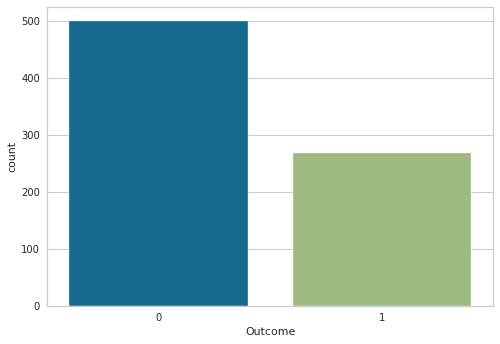

In [58]:
cat_summary(df, "Outcome", True)

In [59]:
def num_summary(dataframe, numerical_col, plot=False):
    quantiles = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]
    print(dataframe[numerical_col].describe(quantiles).T)

    if plot:
        dataframe[numerical_col].hist(bins=20)
        plt.xlabel(numerical_col)
        plt.title(numerical_col)
        plt.show()

                             count      mean       std      min       5%      10%      20%       30%       40%       50%       60%       70%       80%       90%       95%       99%       max
Pregnancies              768.00000   3.84505   3.36958  0.00000  0.00000  0.00000  1.00000   1.00000   2.00000   3.00000   4.00000   5.00000   7.00000   9.00000  10.00000  13.00000  17.00000
Glucose                  768.00000 120.89453  31.97262  0.00000 79.00000 85.00000 95.00000 102.00000 109.00000 117.00000 125.00000 134.00000 147.00000 167.00000 181.00000 196.00000 199.00000
BloodPressure            768.00000  69.10547  19.35581  0.00000 38.70000 54.00000 60.00000  64.00000  68.00000  72.00000  74.00000  78.00000  82.00000  88.00000  90.00000 106.00000 122.00000
SkinThickness            768.00000  20.53646  15.95222  0.00000  0.00000  0.00000  0.00000   8.20000  18.00000  23.00000  27.00000  31.00000  35.00000  40.00000  44.00000  51.33000  99.00000
Insulin                  768.00000  79.79948 

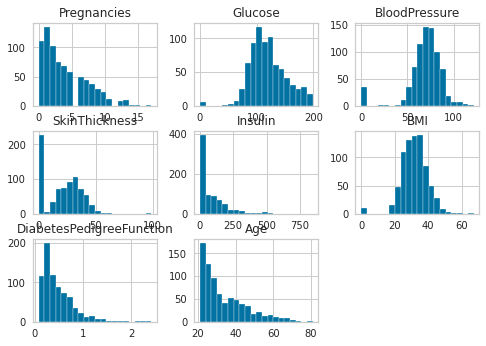

In [60]:
num_summary(df, num_cols, True)

In [61]:
def target_summary_with_num(dataframe, target, numerical_col):
    print(dataframe.groupby(target).agg({numerical_col: "mean"}), end="\n\n\n")

for col in num_cols:
    target_summary_with_num(df, "Outcome", col)

         Pregnancies
Outcome             
0            3.29800
1            4.86567


          Glucose
Outcome          
0       109.98000
1       141.25746


         BloodPressure
Outcome               
0             68.18400
1             70.82463


         SkinThickness
Outcome               
0             19.66400
1             22.16418


          Insulin
Outcome          
0        68.79200
1       100.33582


             BMI
Outcome         
0       30.30420
1       35.14254


         DiabetesPedigreeFunction
Outcome                          
0                         0.42973
1                         0.55050


             Age
Outcome         
0       31.19000
1       37.06716




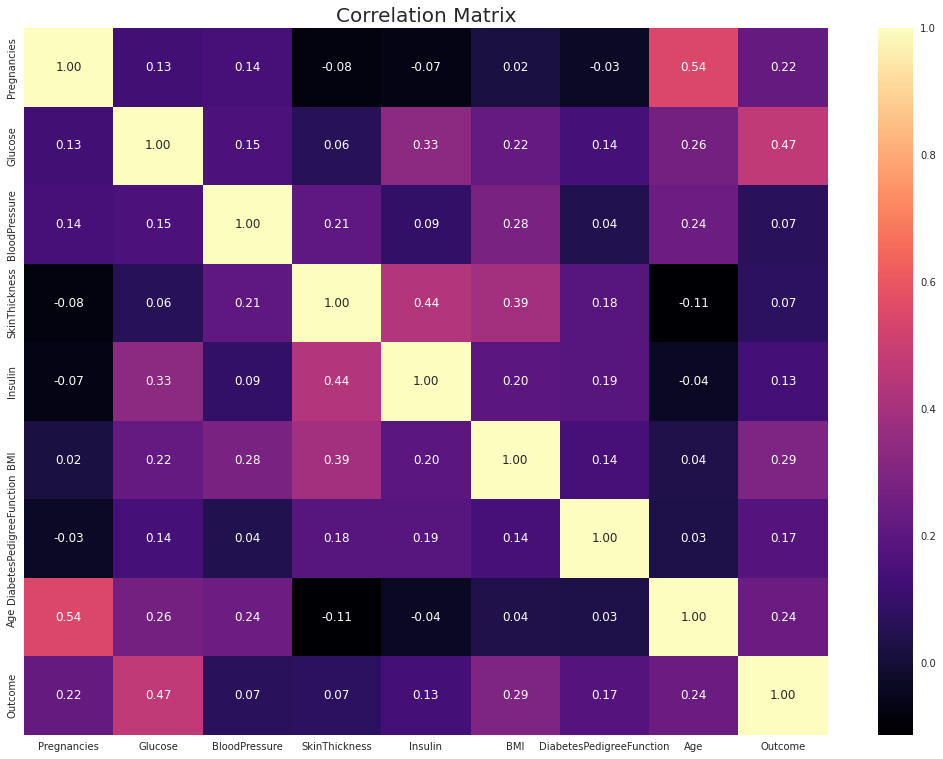

In [62]:
df.corr()

f, ax = plt.subplots(figsize=[18, 13])
sns.heatmap(df.corr(), annot=True, fmt=".2f", ax=ax, cmap="magma")
ax.set_title("Correlation Matrix", fontsize=20)
plt.show()

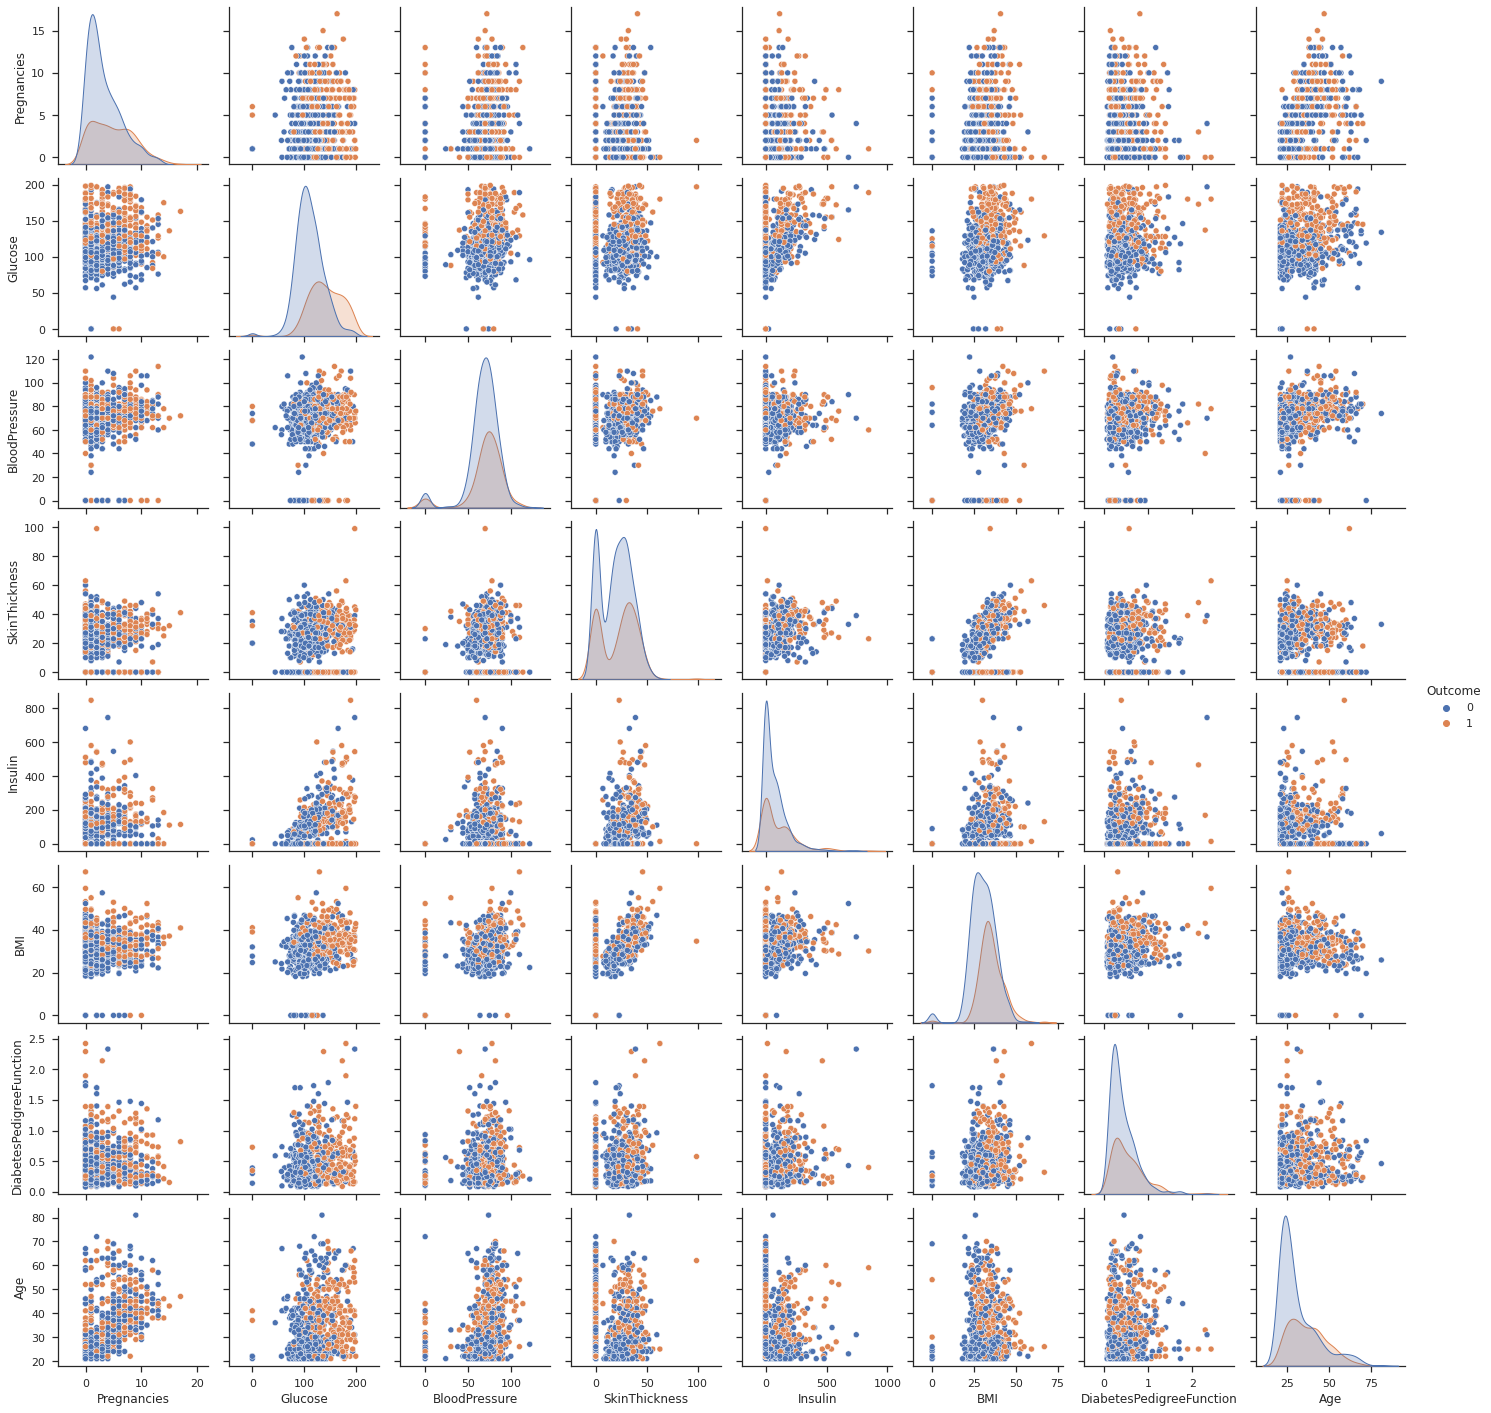

In [63]:
def pairplot(dataset, target_column):
    sns.set(style="ticks")
    sns.pairplot(dataset, hue=target_column)
    plt.show()

pairplot(df, 'Outcome')

In [64]:
Diabetic = df[(df['Outcome'] != 0)]
Non_diabetic = df[(df['Outcome'] == 0)]

In [65]:
data = df.sample(frac=0.95, random_state=786)
data_unseen = df.drop(data.index).reset_index(drop=True)
data.reset_index(drop=True, inplace=True)

print('Data for Modeling: ' + str(data.shape))
print('Unseen Data For Predictions ' + str(data_unseen.shape))

Data for Modeling: (730, 9)
Unseen Data For Predictions (38, 9)


In [66]:
from pycaret.classification import *

In [67]:
clf = setup(data = data, target = 'Outcome',session_id=1229,normalize=True,transformation=True,ignore_low_variance=True,
           remove_multicollinearity=True, multicollinearity_threshold=0.95)

,Description,Value
0,session_id,1229
1,Target,Outcome
2,Target Type,Binary
3,Label Encoded,None
4,Original Data,"(730, 9)"
5,Missing Values,False
6,Numeric Features,7
7,Categorical Features,1
8,Ordinal Features,False
9,High Cardinality Features,False


In [68]:
compare_models(sort='AUC')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.7627,0.8349,0.6199,0.6923,0.6514,0.4731,0.4767,0.0710
lr,Logistic Regression,0.7765,0.8312,0.6190,0.7233,0.6654,0.4993,0.5040,0.5300
catboost,CatBoost Classifier,0.7588,0.8291,0.6088,0.6895,0.6425,0.4626,0.4678,1.4390
lda,Linear Discriminant Analysis,0.7784,0.8279,0.6304,0.7218,0.6707,0.5056,0.5099,0.0110
lightgbm,Light Gradient Boosting Machine,0.7667,0.8172,0.6421,0.6930,0.6645,0.4867,0.4890,0.1350
rf,Random Forest Classifier,0.7471,0.8095,0.5760,0.6790,0.6194,0.4328,0.4386,0.3230
ada,Ada Boost Classifier,0.7373,0.8040,0.5719,0.6558,0.6071,0.4129,0.4172,0.0640
xgboost,Extreme Gradient Boosting,0.7333,0.7987,0.6146,0.6376,0.6245,0.4182,0.4194,14.6510
et,Extra Trees Classifier,0.7216,0.7852,0.5377,0.6232,0.5726,0.3711,0.3751,0.2790
knn,K Neighbors Classifier,0.7451,0.7730,0.5702,0.6723,0.6091,0.4247,0.4325,0.0720


GradientBoostingClassifier(ccp_alpha=0.0, criterion='friedman_mse', init=None,
                           learning_rate=0.1, loss='deviance', max_depth=3,
                           max_features=None, max_leaf_nodes=None,
                           min_impurity_decrease=0.0, min_impurity_split=None,
                           min_samples_leaf=1, min_samples_split=2,
                           min_weight_fraction_leaf=0.0, n_estimators=100,
                           n_iter_no_change=None, presort='deprecated',
                           random_state=1229, subsample=1.0, tol=0.0001,
                           validation_fraction=0.1, verbose=0,
                           warm_start=False)

In [69]:
linear_discriminant_analysis = create_model('lda',fold =10)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,0.7255,0.7714,0.5263,0.6667,0.5882,0.3866,0.3927
1,0.7255,0.7122,0.4737,0.6923,0.5625,0.3726,0.3868
2,0.9020,0.8832,0.8421,0.8889,0.8649,0.7880,0.7887
3,0.8039,0.8766,0.6842,0.7647,0.7222,0.5714,0.5735
4,0.7843,0.8620,0.6111,0.7333,0.6667,0.5092,0.5138
5,0.6863,0.7896,0.5556,0.5556,0.5556,0.3131,0.3131
6,0.8431,0.8855,0.7222,0.8125,0.7647,0.6477,0.6502
7,0.8431,0.8569,0.6667,0.8571,0.7500,0.6383,0.6490
8,0.7843,0.8586,0.7222,0.6842,0.7027,0.5337,0.5341
9,0.6863,0.7828,0.5000,0.5625,0.5294,0.2953,0.2965


In [70]:
tuned_linear_discriminant_analysis= tune_model(linear_discriminant_analysis)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,0.7647,0.7961,0.6316,0.7059,0.6667,0.4857,0.4875
1,0.7647,0.7253,0.5263,0.7692,0.6250,0.4622,0.4799
2,0.8824,0.8947,0.8421,0.8421,0.8421,0.7484,0.7484
3,0.7843,0.8750,0.6842,0.7222,0.7027,0.5337,0.5341
4,0.7843,0.8502,0.6111,0.7333,0.6667,0.5092,0.5138
5,0.7059,0.7862,0.5556,0.5882,0.5714,0.3478,0.3482
6,0.8431,0.8939,0.7222,0.8125,0.7647,0.6477,0.6502
7,0.8431,0.8620,0.6667,0.8571,0.7500,0.6383,0.6490
8,0.7451,0.8300,0.6111,0.6471,0.6286,0.4348,0.4352
9,0.6863,0.8182,0.5000,0.5625,0.5294,0.2953,0.2965


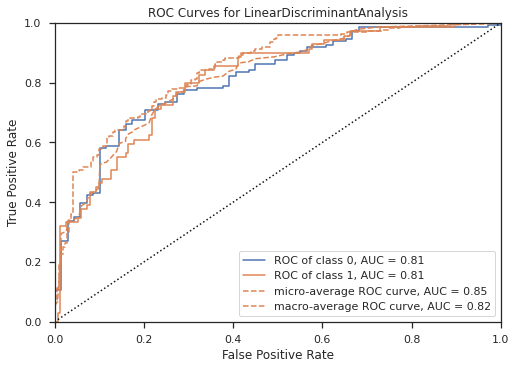

In [71]:
plot_model(tuned_linear_discriminant_analysis)

In [72]:
predict_model(tuned_linear_discriminant_analysis)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Linear Discriminant Analysis,0.7500,0.8138,0.5507,0.6129,0.5802,0.4029,0.4041


,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Pregnancies_0,Pregnancies_1,Pregnancies_10,...,Pregnancies_3,Pregnancies_4,Pregnancies_5,Pregnancies_6,Pregnancies_7,Pregnancies_8,Pregnancies_9,Outcome,Label,Score
0,-0.95409,0.22783,0.88419,-0.07116,-0.14267,-1.10509,-1.04099,0.00000,1.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0,0,0.96870
1,-0.35152,-0.65950,1.60600,1.27624,0.42014,0.14532,-0.87484,0.00000,1.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0,0,0.86070
2,-0.60319,1.14801,2.43443,0.86704,1.86687,1.45770,0.09002,1.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0,0,0.54140
3,0.58750,0.51147,-1.26532,-0.91189,-0.68797,1.99986,1.64171,0.00000,0.00000,1.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0,1,0.73630
4,-0.44551,0.16074,-1.26532,-0.91189,-1.19893,0.65569,1.49250,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0,0,0.80250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215,0.08004,0.98055,-1.26532,-0.91189,0.31614,-0.48406,0.30073,0.00000,0.00000,0.00000,...,0.00000,0.00000,1.00000,0.00000,0.00000,0.00000,0.00000,0,0,0.63800
216,-0.41413,-0.15070,-1.26532,-0.91189,0.25099,-0.71775,1.45253,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0,1,0.50080
217,-0.53997,-0.47120,1.60600,0.55573,1.07754,0.45635,-1.39417,1.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0,0,0.81170
218,-0.44551,-0.47120,1.30679,1.08922,1.19271,-1.23851,-1.21411,1.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0,0,0.82500


In [73]:
final_model = finalize_model(tuned_linear_discriminant_analysis)

In [74]:
unseen_predictions = predict_model(final_model, data=data_unseen)
unseen_predictions

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Label,Score
0,5,116,74,0,0,25.60000,0.20100,30,0,0,0.87630
1,1,146,56,0,0,29.70000,0.56400,29,0,1,0.53600
2,7,103,66,32,0,39.10000,0.34400,31,1,0,0.61990
3,1,71,48,18,76,20.40000,0.32300,22,0,0,0.99040
4,2,107,74,30,100,33.60000,0.40400,23,0,0,0.90170
5,3,170,64,37,225,34.50000,0.35600,30,1,1,0.75430
6,6,85,78,0,0,31.20000,0.38200,42,0,0,0.89390
7,1,138,82,0,0,40.10000,0.23600,28,0,0,0.56790
8,0,108,68,20,0,27.30000,0.78700,32,0,0,0.74070
9,7,179,95,31,0,34.20000,0.16400,60,0,1,0.86060
